# Wikispeedia Navigation Paths

https://snap.stanford.edu/data/wikispeedia.html

"This dataset contains human navigation paths on Wikipedia, collected through the human-computation game Wikispeedia. In Wikispeedia, users are asked to navigate from a given source to a given target article, by only clicking Wikipedia links. A condensed version of Wikipedia (4,604 articles) is used. In addition to the navigation paths, we provide the full HTML package of this version of Wikipedia, as well as all articles in plaintext."

Rating is from 1 ("easy") to 5 ("brutal")


## 1. Imports and load data

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np  
import pandas as pd 
import plotly.graph_objs as go
import seaborn as sns
import warnings
import urllib.parse


from scipy import stats

from flow_tree_utils import generate_trajs_from_df, load_test_df, OBJECTS, generate_flow_tree_from_trajs, plot_flow_tree


In [2]:
def make_distribution_plot(data, jitter_high=0.3, y_start=0, x_label="", x_ticks=np.arange(0, 1.1, 0.5), log_scale=False, figsize=(8, 8)):
    fig, ax = plt.subplots(figsize=figsize)

    COLORS = ["#FF5A5F", "#FFB400", "#007A87"]

    # Half-violin plot as above
    # pt.half_violinplot(
    #     x=subj_mean_accs, #y="species", 
    #     palette=COLORS, 
    #     inner=None,  width=1, ax=ax
    # )
    sns.kdeplot(data, color = 'darkblue', log_scale=log_scale, linewidth=4, ax=ax)

    # Jitter the values on the vertical axis
    y = y_start + np.random.uniform(high=ax.get_ylim()[1]*jitter_high, size=len(data))

    # Add the rain using the scatter method.
    ax.scatter(data, y, color=COLORS[0], alpha=0.005, s=5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2.5)
    ax.yaxis.set_visible(False)

    ax.tick_params(axis='both', which='major', labelsize=15, width=2, length=10)
    plt.xticks(x_ticks)
    plt.xlabel(x_label, fontsize=15)
    plt.xlim(0,x_ticks[-1])
    plt.show()

### Load articles and categories

In [3]:
data_path = "data/wikispeedia_paths-and-graph"

# load article names
article_names = []
with open(f"{data_path}/articles.tsv") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#": continue

        # decoded_line = urllib.parse.unquote(line)
        # maybe leave in URL encoding bc the 
        article_names.append(line)

# load shortest paths


def get_nth_category(category_string, n):
    category_list = category_string.split(".")
    if len(category_list) <= n:
        return pd.NA
    return category_list[n]

# load categories
column_names = ["article", "category"]
categories_df = pd.read_csv(f"{data_path}/categories.tsv", names=column_names, sep='\t', skiprows=[i for i in range(13)])
categories_df["num_categories"] = categories_df["category"].apply(lambda x: len(x.split(".")))
print("Max category depth is", categories_df["num_categories"].max())
for i in range(categories_df["num_categories"].max()):
    categories_df[f"category{i}"] = categories_df["category"].apply(lambda x: get_nth_category(x, i))
categories_df


Max category depth is 4


,article,category,num_categories,category0,category1,category2,category3
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,subject.History.British_History.British_Histor...,4,subject,History,British_History,British_History_1500_and_before_including_Roma...
1,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,subject.People.Historical_figures,3,subject,People,Historical_figures,<NA>
2,%C3%85land,subject.Countries,2,subject,Countries,<NA>,<NA>
3,%C3%85land,subject.Geography.European_Geography.European_...,4,subject,Geography,European_Geography,European_Countries
4,%C3%89douard_Manet,subject.People.Artists,3,subject,People,Artists,<NA>
...,...,...,...,...,...,...,...
5199,Zirconium,subject.Science.Chemistry.Chemical_elements,4,subject,Science,Chemistry,Chemical_elements
5200,Zoroaster,subject.People.Religious_figures_and_leaders,3,subject,People,Religious_figures_and_leaders,<NA>
5201,Zuid-Gelders,subject.Geography.European_Geography,3,subject,Geography,European_Geography,<NA>
5202,Zuid-Gelders,subject.Language_and_literature.Languages,3,subject,Language_and_literature,Languages,<NA>


### Load edges

In [4]:
# load links
column_names = ["linkSource", "linkTarget"]
edges_df = pd.read_csv(f"{data_path}/links.tsv", names=column_names, sep='\t', skiprows=[i for i in range(13)])
edge_dict = dict(zip(edges_df.linkSource, edges_df.linkTarget))

In [5]:
max_category_depth = categories_df["num_categories"].max()

category_level_dict = {}
for i in range(max_category_depth):
    for cat in categories_df[f"category{i}"].dropna():
        category_level_dict[cat] = i

for _, row in categories_df.iterrows():
    category_level_dict[row["article"]] = row["num_categories"]

edge_level_dict = {}
for k, v in edge_dict.items():
    if k not in category_level_dict or v not in category_level_dict:
        continue
    edge_level_dict[(k, v)] = category_level_dict[v] - category_level_dict[k]

### Load trajectories

In [6]:
def get_nth_article(article_string, n):
    article_list = article_string.split(";")
    return article_list[n]

def get_path_len(x):
    return len(x.split(";"))

def get_least_common_level(art1, art2):
    art1_row = categories_df[categories_df["article"]==art1]
    art2_row = categories_df[categories_df["article"]==art2]

    if len(art1_row) == 0 or len(art2_row) == 0: return None
    
    lcl = None
    for i in range(max_category_depth):
        art1_cat = art1_row[f"category{i}"].iloc[0]
        art2_cat = art2_row[f"category{i}"].iloc[0] # sometimes there are two categories got to fix

        if pd.isna(art1_cat) or pd.isna(art2_cat) or art1_cat != art2_cat:
            return lcl
        else:
            lcl = i
    return lcl

    # for i in range([f"category{i}"]
def get_levels_traj(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(category_level_dict.get(articles[j], None))
                    break
        else:
            traj.append(category_level_dict.get(article, None))
    return traj

def get_level_hops(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(articles[j])
                    break
        else:
            traj.append(article)

    lcls = []
    for i in range(len(traj)-1):
        a, b = traj[i], traj[i+1]
        lcls.append(get_least_common_level(a, b))
    return lcls


# load successful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
finished_trajs_df = pd.read_csv(f"{data_path}/paths_finished.tsv", names=column_names, sep='\t', skiprows=[i for i in range(16)])
finished_trajs_df["StartAt"] = finished_trajs_df["path"].apply(lambda x: get_nth_article(x, 0))
finished_trajs_df["EndAt"] = finished_trajs_df["path"].apply(lambda x: get_nth_article(x, -1))
finished_trajs_df["finished"] = True

# load unsuccessful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "target", "type"]
unfinished_trajs_df = pd.read_csv(f"{data_path}/paths_unfinished.tsv", names=column_names, sep='\t', skiprows=[i for i in range(17)])
unfinished_trajs_df["StartAt"] = unfinished_trajs_df["path"].apply(lambda x: get_nth_article(x, 0))
unfinished_trajs_df["EndAt"] = unfinished_trajs_df["target"]
unfinished_trajs_df["finished"] = False

trajs_df = pd.concat([finished_trajs_df, unfinished_trajs_df])
trajs_df.reset_index()
trajs_df["traj_len"] = trajs_df["path"].apply(get_path_len)
trajs_df["levels_traj"] = trajs_df["path"].apply(get_levels_traj)
trajs_df["level_hops"] = trajs_df["path"].apply(get_level_hops)


trajs_df


,hashedIpAddress,timestamp,durationInSec,path,rating,StartAt,EndAt,finished,target,type,traj_len,levels_traj,level_hops
0,6a3701d319fc3754,1297740409,166,14th_century;15th_century;16th_century;Pacific...,NaN,14th_century,African_slave_trade,True,NaN,NaN,9,"[3, 3, 3, 3, 3, 3, 3, 4, 3]","[2, 2, 0, 2, 1, 2, 0, 1]"
1,3824310e536af032,1344753412,88,14th_century;Europe;Africa;Atlantic_slave_trad...,3.0,14th_century,African_slave_trade,True,NaN,NaN,5,"[3, 3, 3, 4, 3]","[0, 1, 0, 1]"
2,415612e93584d30e,1349298640,138,14th_century;Niger;Nigeria;British_Empire;Slav...,NaN,14th_century,African_slave_trade,True,NaN,NaN,8,"[3, 2, 2, 3, 3, 3, 4, 3]","[0, 3, 0, 0, 0, 0, 1]"
3,64dd5cd342e3780c,1265613925,37,14th_century;Renaissance;Ancient_Greece;Greece,NaN,14th_century,Greece,True,NaN,NaN,4,"[3, 3, 3, 4]","[2, 1, 0]"
4,015245d773376aab,1366730828,175,14th_century;Italy;Roman_Catholic_Church;HIV;R...,3.0,14th_century,John_F._Kennedy,True,NaN,NaN,7,"[3, 4, 3, 4, 3, 3, 3]","[0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24870,109ed71f571d86e9,1389787605,180,Franz_Kafka;Tuberculosis;World_Health_Organiza...,NaN,Franz_Kafka,Cholera,False,Cholera,restart,8,"[3, 4, 3, 4, 2, 2, 3, 2]","[0, 0, 0, 0, 3, 1, 2]"
24871,232f992e57d43e8d,1389787697,6,Modern_history,NaN,Modern_history,Hollandic,False,Hollandic,restart,1,[3],[]
24872,2e09a7224600a7cd,1389798400,1900,Computer_programming;Linguistics;Culture;Popul...,NaN,Computer_programming,The_Beatles,False,The_Beatles,timeout,5,"[3, 3, 3, 3, 3]","[0, 0, 0, 2]"
24873,60af9e2138051b96,1389799481,1903,Jamaica;United_Kingdom;World_War_II;Battle_of_...,NaN,Jamaica,Alan_Turing,False,Alan_Turing,timeout,4,"[2, 3, 4, 3]","[0, 0, 1]"


### Process trajectories

In [7]:
# nodes need to be strings apparently
article_to_index = {article: str(i) for i, article in enumerate(article_names)}
index_to_article = {str(i): article for i, article in enumerate(article_names)}

def decode_path_to_traj(path):
    traj = []
    articles = path.split(";")
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i-1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(article_to_index[articles[j]])
                    break
        else:
            traj.append(article_to_index[article])
    return traj

trajs_df["traj"] = trajs_df["path"].apply(decode_path_to_traj) 
trajs_df["StartEnd"] = trajs_df["StartAt"] + "_" + trajs_df["EndAt"]

trajs_df["avg_rating"] = trajs_df.groupby("StartEnd")["rating"].transform("mean")

trajs_df[["StartEnd", "traj", "avg_rating"]]


,StartEnd,traj,avg_rating
0,14th_century_African_slave_trade,"[10, 12, 15, 3134, 377, 105, 128, 379, 143]",3.0
1,14th_century_African_slave_trade,"[10, 1433, 128, 379, 143]",3.0
2,14th_century_African_slave_trade,"[10, 2982, 2984, 694, 3755, 128, 379, 143]",3.0
3,14th_century_Greece,"[10, 3464, 241, 1793]",NaN
4,14th_century_John_F._Kennedy,"[10, 2183, 3529, 1836, 3542, 3342, 2266]",3.0
...,...,...,...
24870,Franz_Kafka_Cholera,"[1585, 4247, 4538, 2614, 3223, 3223, 3917, 1696]",NaN
24871,Modern_history_Hollandic,[2802],NaN
24872,Computer_programming_The_Beatles,"[1008, 2478, 1098, 3315, 3315]",4.0
24873,Jamaica_Alan_Turing,"[2205, 4293, 4542, 506]",NaN


## 2. Analyse top 100

### Take k=100 most common trajectories

In [202]:
trajs_df.columns

Index(['hashedIpAddress', 'timestamp', 'durationInSec', 'path', 'rating',
       'StartAt', 'EndAt', 'finished', 'target', 'type', 'traj_len',
       'levels_traj', 'level_hops', 'traj', 'StartEnd', 'avg_rating'],
      dtype='object')

In [8]:
# maybe first filter out multiple of the same ip address
trajs_df = trajs_df.drop_duplicates(subset=["hashedIpAddress", "StartEnd"], keep="last")

In [44]:
# find most common tasks
k = 50
most_common_paths = trajs_df["StartEnd"].value_counts()[:k].index.tolist()

print(f"Most common task is {most_common_paths[0]} with {len(trajs_df[trajs_df['StartEnd'] == most_common_paths[0]]['traj'])} attempts.")
print(f"{k}th most common task is {most_common_paths[-1]} with {len(trajs_df[trajs_df['StartEnd'] == most_common_paths[-1]]['traj'])} attempts")

reduced_trajs_df = trajs_df[trajs_df["StartEnd"].isin(most_common_paths)].copy()

Most common task is Brain_Telephone with 1742 attempts.
50th most common task is Canada_Pony with 22 attempts


In [79]:
reduced_trajs_df.columns

Index(['hashedIpAddress', 'timestamp', 'durationInSec', 'path', 'rating',
       'StartAt', 'EndAt', 'finished', 'target', 'type', 'traj_len',
       'levels_traj', 'level_hops', 'traj', 'StartEnd', 'avg_rating'],
      dtype='object')

### V basic

In [80]:
reduced_trajs_df.describe(include='all')

,hashedIpAddress,timestamp,durationInSec,path,rating,StartAt,EndAt,finished,target,type,traj_len,levels_traj,level_hops,traj,StartEnd,avg_rating
count,10983,1.098300e+04,10983.000000,10983,2195.000000,10983,10983,10983,4774,4774,10983.000000,10983,10983,10983,10983,10962.000000
unique,5342,NaN,NaN,7059,NaN,61,79,2,77,2,NaN,2215,3154,7059,100,NaN
top,7d5624e35c9523ef,NaN,NaN,Brain,NaN,Brain,Telephone,True,Telephone,restart,NaN,[3],[],[678],Brain_Telephone,NaN
freq,188,NaN,NaN,207,NaN,2044,2163,6209,1052,2974,NaN,455,891,207,2044,NaN
mean,NaN,1.338044e+09,452.462169,NaN,2.515718,NaN,NaN,NaN,NaN,NaN,6.004826,NaN,NaN,NaN,NaN,2.543536
std,NaN,3.075026e+07,754.358399,NaN,1.089899,NaN,NaN,NaN,NaN,NaN,4.072159,NaN,NaN,NaN,NaN,0.405356
min,NaN,1.219102e+09,1.000000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,NaN,1.312038e+09,75.000000,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,2.482051
50%,NaN,1.345430e+09,141.000000,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,2.554455
75%,NaN,1.354218e+09,310.000000,NaN,3.000000,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,NaN,NaN,NaN,2.677419


### User level

In [81]:
user_counts = reduced_trajs_df['hashedIpAddress'].value_counts()
user_counts.describe()

count    5342.000000
mean        2.055972
std         4.191410
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       188.000000
Name: count, dtype: float64

In [82]:
user_counts

hashedIpAddress
7d5624e35c9523ef    188
0d57c8c57d75e2f5    102
5f22535607b1d77d     82
36691f800d571743     64
126c53a444812f50     55
                   ... 
3be83de02ce6f018      1
07875ba6084f019c      1
3ae706e4313bdbf8      1
615a5fe40472c2d0      1
3f37dcd33d2b1215      1
Name: count, Length: 5342, dtype: int64

Text(0.5, 1.0, 'LOG Distribution of user activity')

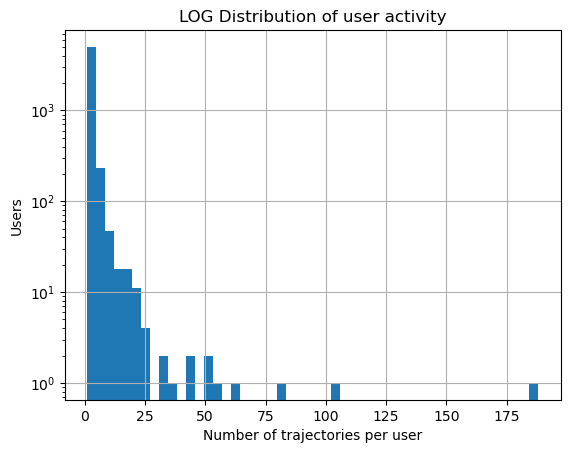

In [83]:
user_counts.hist(bins=50, log=True)
plt.xlabel("Number of trajectories per user")
plt.ylabel("Users")
plt.title("LOG Distribution of user activity")

# make_distribution_plot(user_counts, x_label="", x_ticks=[0, 4, 8, 12, 20], log_scale=False, figsize=(3,3))

### Duration

In [84]:
reduced_trajs_df['durationInSec'].describe()

count    10983.000000
mean       452.462169
std        754.358399
min          1.000000
25%         75.000000
50%        141.000000
75%        310.000000
max      34009.000000
Name: durationInSec, dtype: float64

In [91]:
reduced_trajs_df[reduced_trajs_df["type"] != "restart"][["finished", "durationInSec", "type"]]

,finished,durationInSec,type
7,True,139,NaN
8,True,74,NaN
9,True,167,NaN
10,True,253,NaN
11,True,218,NaN
...,...,...,...
24666,False,1847,timeout
24801,False,1805,timeout
24808,False,1861,timeout
24811,False,1806,timeout


/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_17336/3624016575.py:28: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,x_ticks[-1])


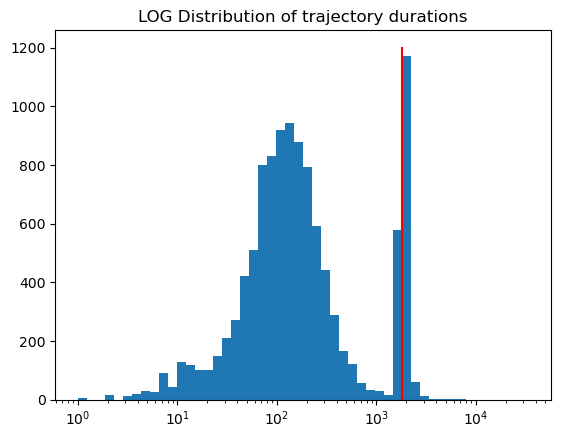

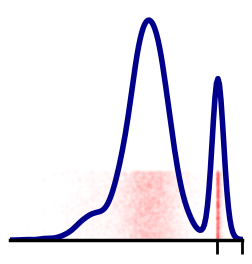

In [172]:
hist, bins = np.histogram(reduced_trajs_df['durationInSec'], bins=50)

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.hist(reduced_trajs_df['durationInSec'], bins=logbins)

plt.plot([30*60, 30*60],[0,1200],c="red")
plt.xscale('log')
plt.title("LOG Distribution of trajectory durations")

make_distribution_plot(reduced_trajs_df['durationInSec'], x_label="", x_ticks=[0, 1800, 5000], log_scale=True, figsize=(3,3))


### Trajectory length

In [93]:
trajs_df['StartEnd'].value_counts().head(20)

StartEnd
Brain_Telephone              2044
Theatre_Zebra                1777
Asteroid_Viking              1770
Pyramid_Bean                 1586
Batman_Wood                   223
Bird_Great_white_shark        168
Batman_The_Holocaust          149
Beer_Sun                      142
Bird_Adolf_Hitler             129
Batman_Banana                 125
Cat_Computer                  100
Cat_Microsoft                  98
Dog_Telephone                  89
Aircraft_Google                78
Dog_Venus                      71
Computer_Fruit                 65
Aluminium_chloride_Parrot      64
Batman_Penguin                 60
Automobile_Pluto               59
England_God                    58
Name: count, dtype: int64

Text(0.5, 1.0, 'LOG Distribution of trajectory lengths')

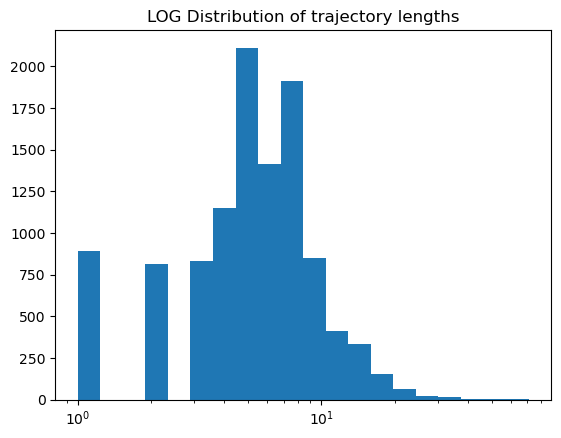

In [97]:
hist, bins = np.histogram(reduced_trajs_df['traj_len'], bins=20)

logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.hist(reduced_trajs_df['traj_len'], bins=logbins)

plt.xscale('log')
plt.title("LOG Distribution of trajectory lengths")

Finished trajectory lengths


/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_17336/3624016575.py:28: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,x_ticks[-1])


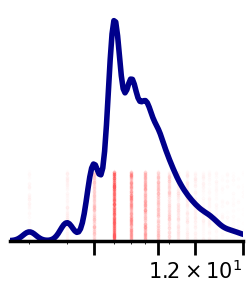

Uninished trajectory lengths


/var/folders/24/lp6939qs6f1d149198s_3mv40000gn/T/ipykernel_17336/3624016575.py:28: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0,x_ticks[-1])


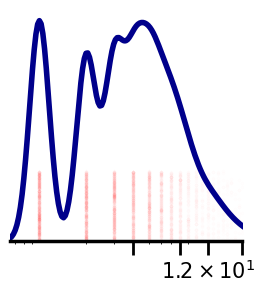

In [100]:
print("Finished trajectory lengths")
make_distribution_plot(reduced_trajs_df[reduced_trajs_df["finished"]]["traj_len"], x_label="", x_ticks=[0, 4, 8, 12, 20], log_scale=True, figsize=(3,3))

print("Uninished trajectory lengths")
make_distribution_plot(reduced_trajs_df[~reduced_trajs_df["finished"]]["traj_len"], x_label="", x_ticks=[0, 4, 8, 12, 20], log_scale=True, figsize=(3,3))

Mean traj len: 6.005, std: 4.072


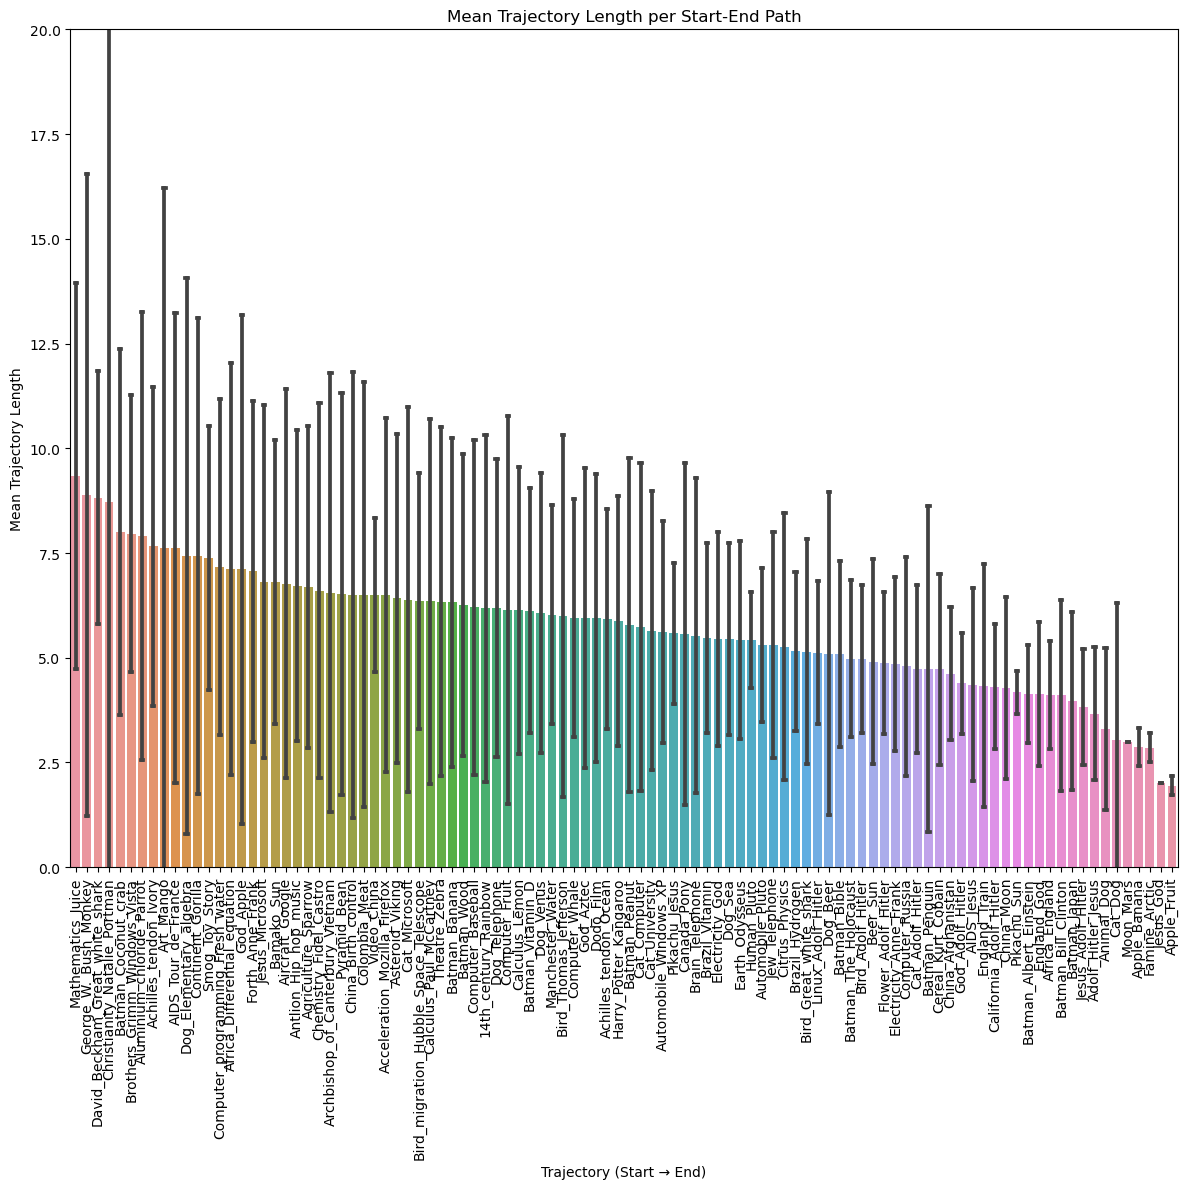

In [101]:
print(f"Mean traj len: {reduced_trajs_df['traj_len'].mean():0.3f}, std: {reduced_trajs_df['traj_len'].std():0.3f}")

# Sort by mean traj_len
order = (
    reduced_trajs_df.groupby("StartEnd")["traj_len"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 12))
sns.barplot(
    data=reduced_trajs_df,
    x="StartEnd",
    y="traj_len",
    ci="sd",  # use standard deviation instead of CI
    order=order,
    capsize=0.2,
)

plt.ylim(0,20)

plt.xticks(rotation=90)
plt.xlabel("Trajectory (Start → End)")
plt.ylabel("Mean Trajectory Length")
plt.title("Mean Trajectory Length per Start-End Path")
plt.tight_layout()
plt.show()

In [174]:
len(set(reduced_trajs_df["StartAt"]))

61

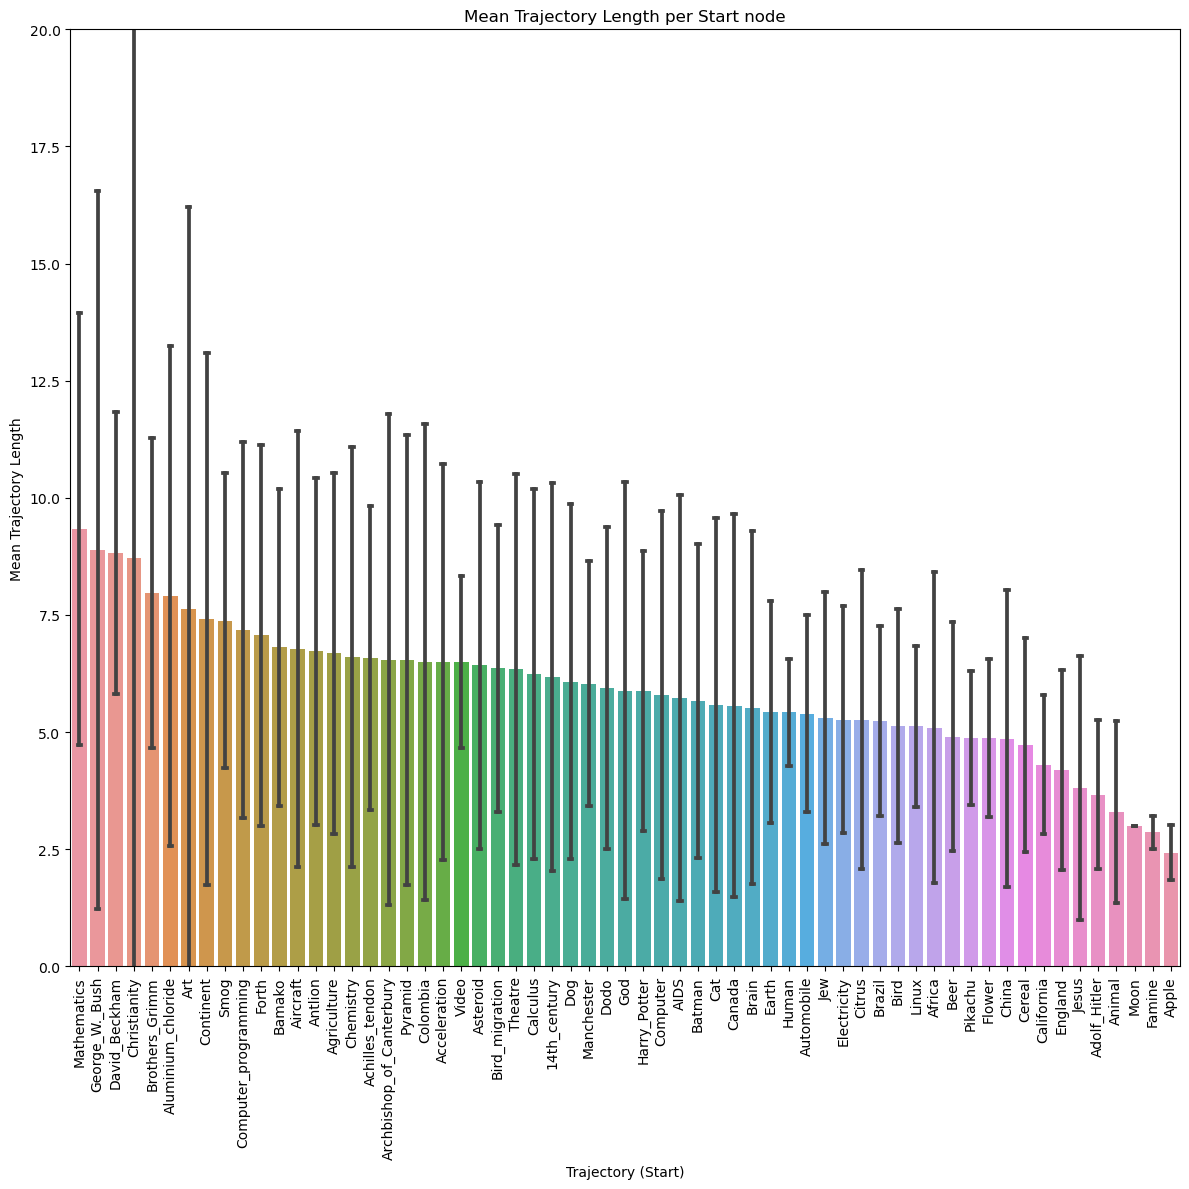

In [120]:
# Sort by mean traj_len
order = (
    reduced_trajs_df.groupby("StartAt")["traj_len"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 12))
sns.barplot(
    data=reduced_trajs_df,
    x="StartAt",
    y="traj_len",
    ci="sd",  # use standard deviation instead of CI
    order=order,
    capsize=0.2,
)

plt.ylim(0,20)

plt.xticks(rotation=90)
plt.xlabel("Trajectory (Start)")
plt.ylabel("Mean Trajectory Length")
plt.title("Mean Trajectory Length per Start node")
plt.tight_layout()
plt.show()

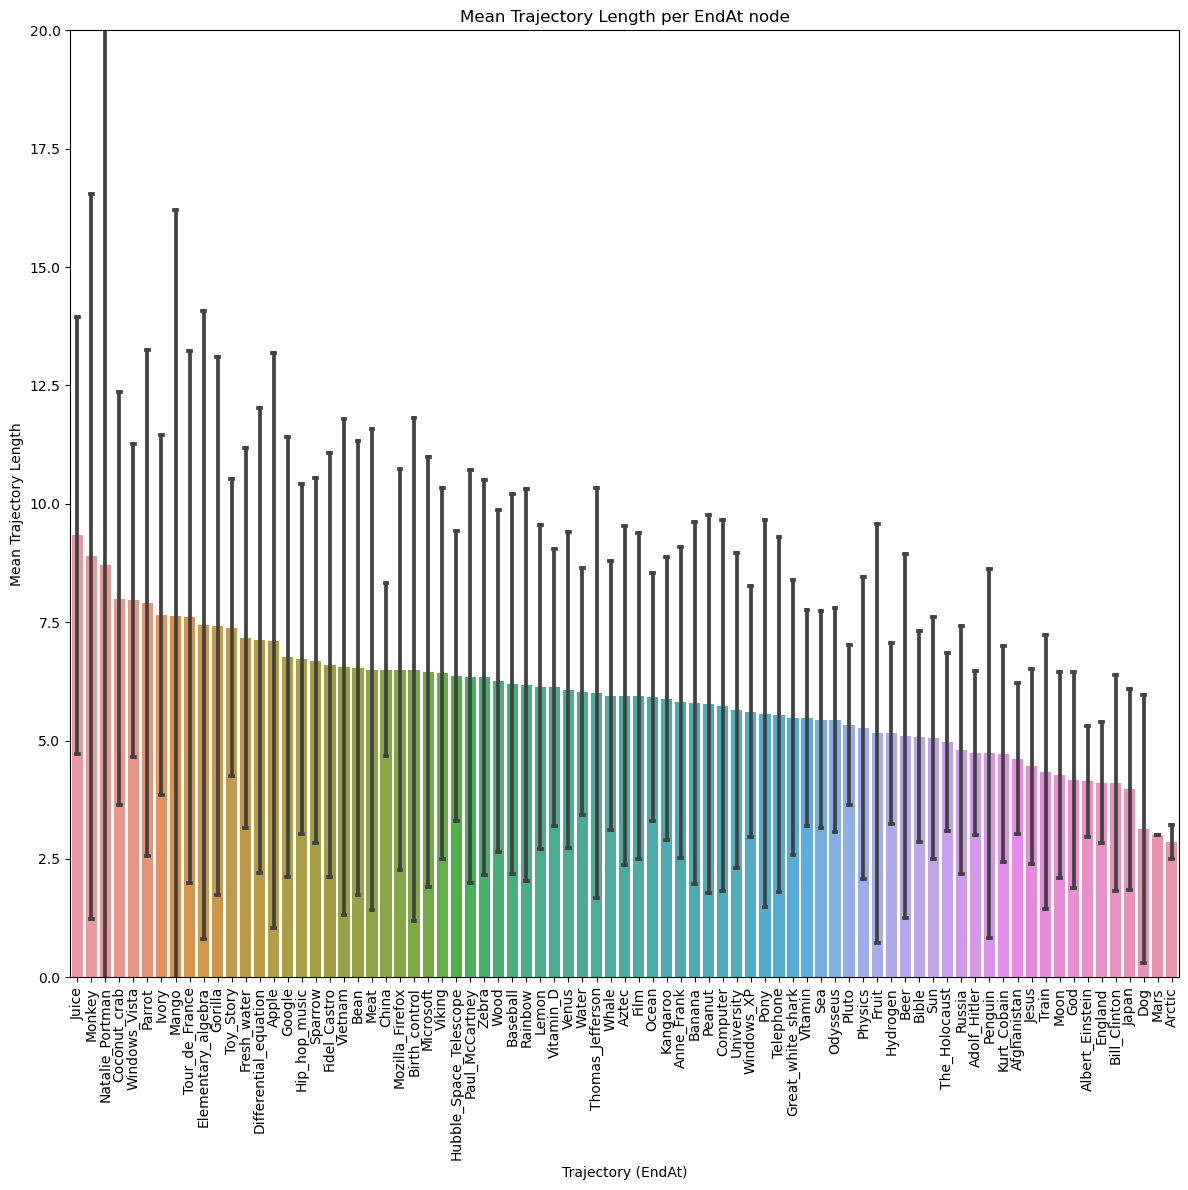

In [121]:
# Sort by mean traj_len
order = (
    reduced_trajs_df.groupby("EndAt")["traj_len"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 12))
sns.barplot(
    data=reduced_trajs_df,
    x="EndAt",
    y="traj_len",
    ci="sd",  # use standard deviation instead of CI
    order=order,
    capsize=0.2,
)

plt.ylim(0,20)

plt.xticks(rotation=90)
plt.xlabel("Trajectory (EndAt)")
plt.ylabel("Mean Trajectory Length")
plt.title("Mean Trajectory Length per EndAt node")
plt.tight_layout()
plt.show()

### Performance

Text(0.5, 1.0, 'Distribution of ratings')

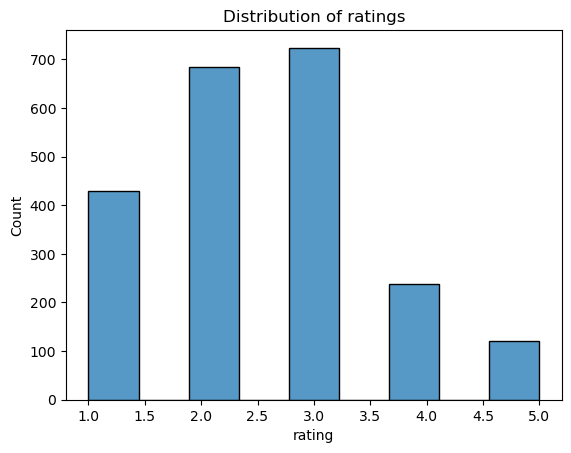

In [110]:
sns.histplot(reduced_trajs_df['rating'], bins=9)
plt.title("Distribution of ratings")

Text(0.5, 1.0, 'Rating by startat')

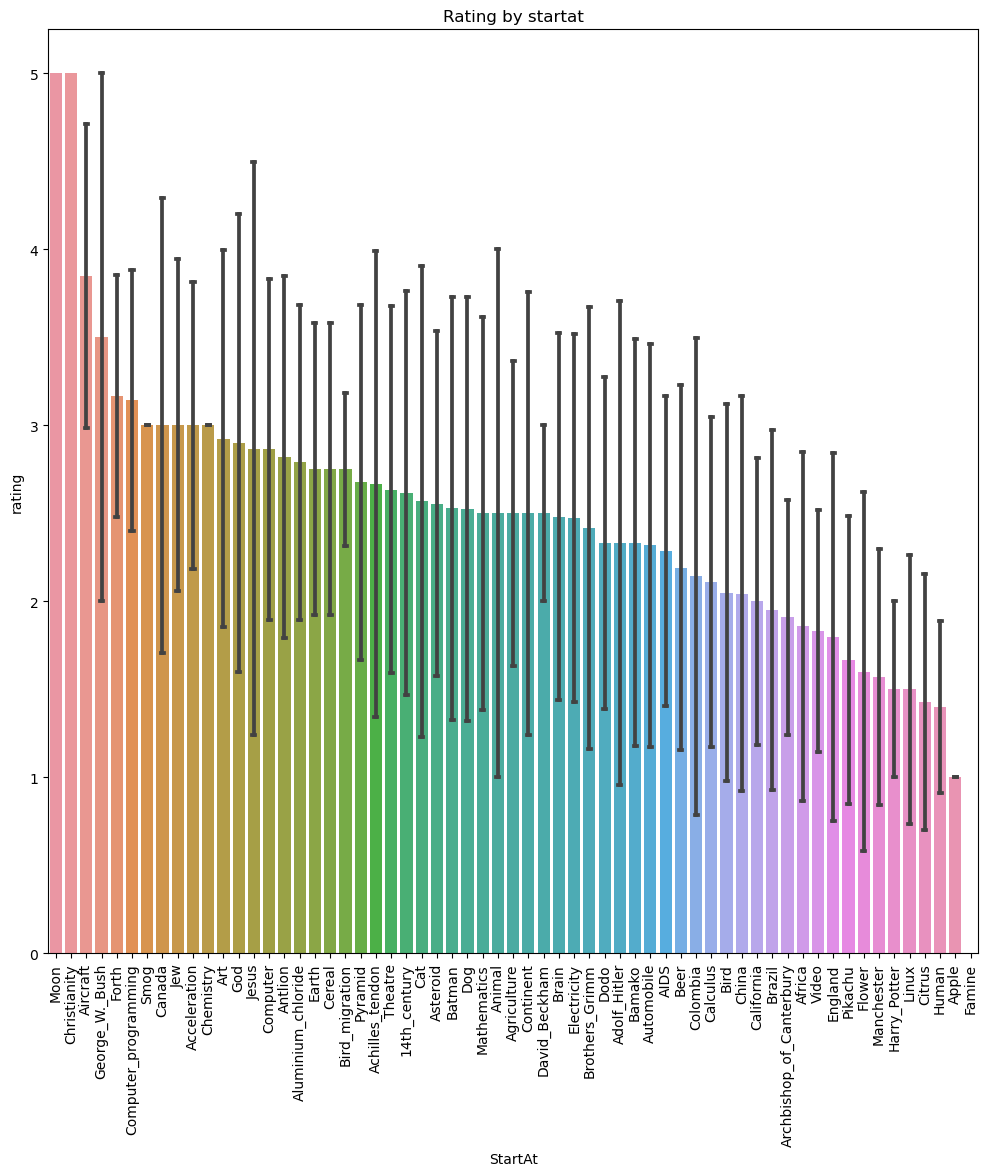

In [ ]:
order = (
    reduced_trajs_df.groupby("StartAt")["rating"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 12))
sns.barplot(
    data=reduced_trajs_df,
    x="StartAt",
    y="rating",
    ci="sd",  # use standard deviation instead of CI
    order=order,
    capsize=0.2,
)
plt.xticks(rotation=90)
plt.title("Rating by startat")

Text(0.5, 1.0, 'Rating by EndAt')

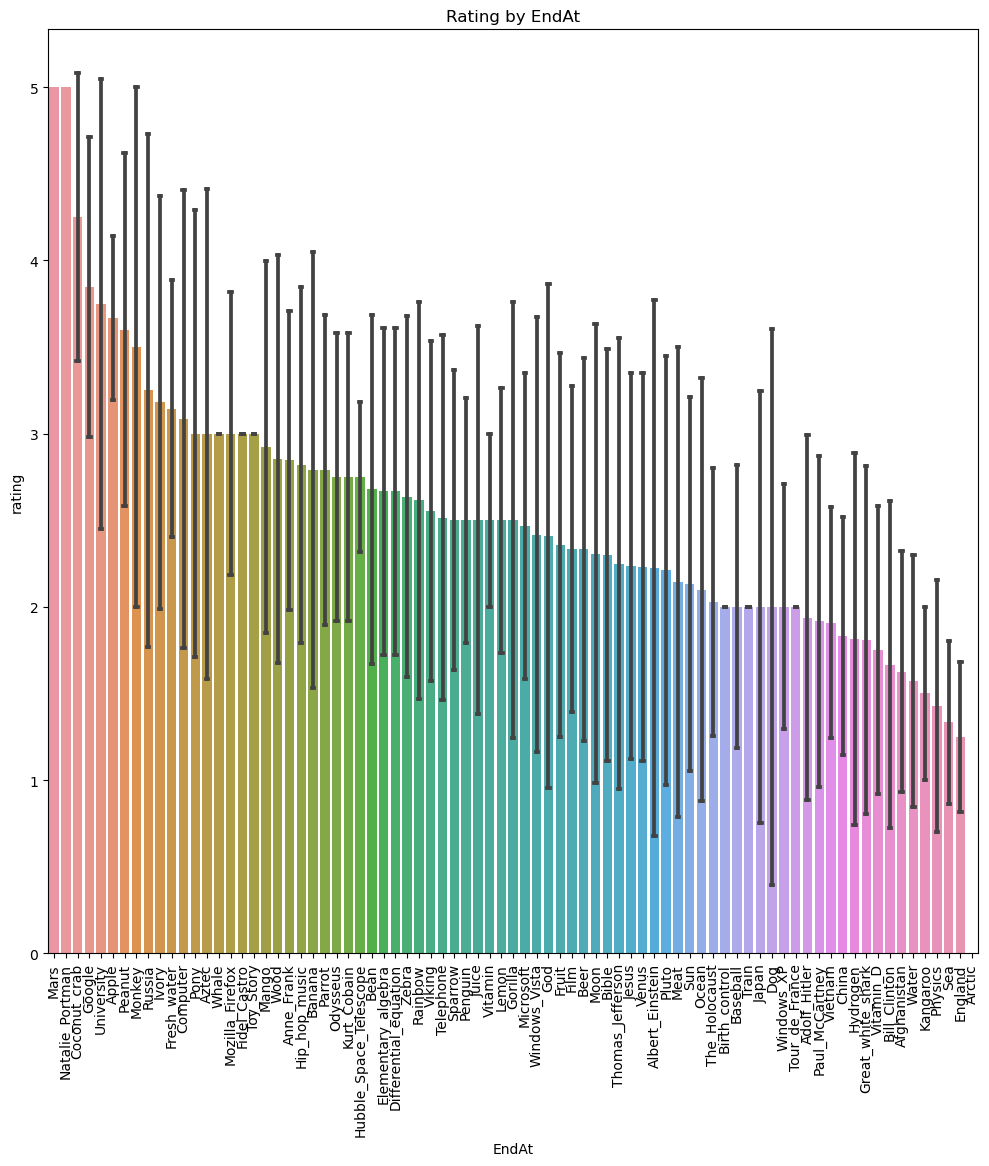

In [118]:
order = (
    reduced_trajs_df.groupby("EndAt")["rating"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 12))
sns.barplot(
    data=reduced_trajs_df,
    x="EndAt",
    y="rating",
    ci="sd",  # use standard deviation instead of CI
    order=order,
    capsize=0.2,
)
plt.xticks(rotation=90)
plt.title("Rating by EndAt")

### Completion rate

In [126]:
completion_rate = reduced_trajs_df['finished'].mean()
print(f"Completion rate: {completion_rate:.2%}")

Completion rate: 56.53%


Text(0.5, 1.0, 'Completion by StartAt')

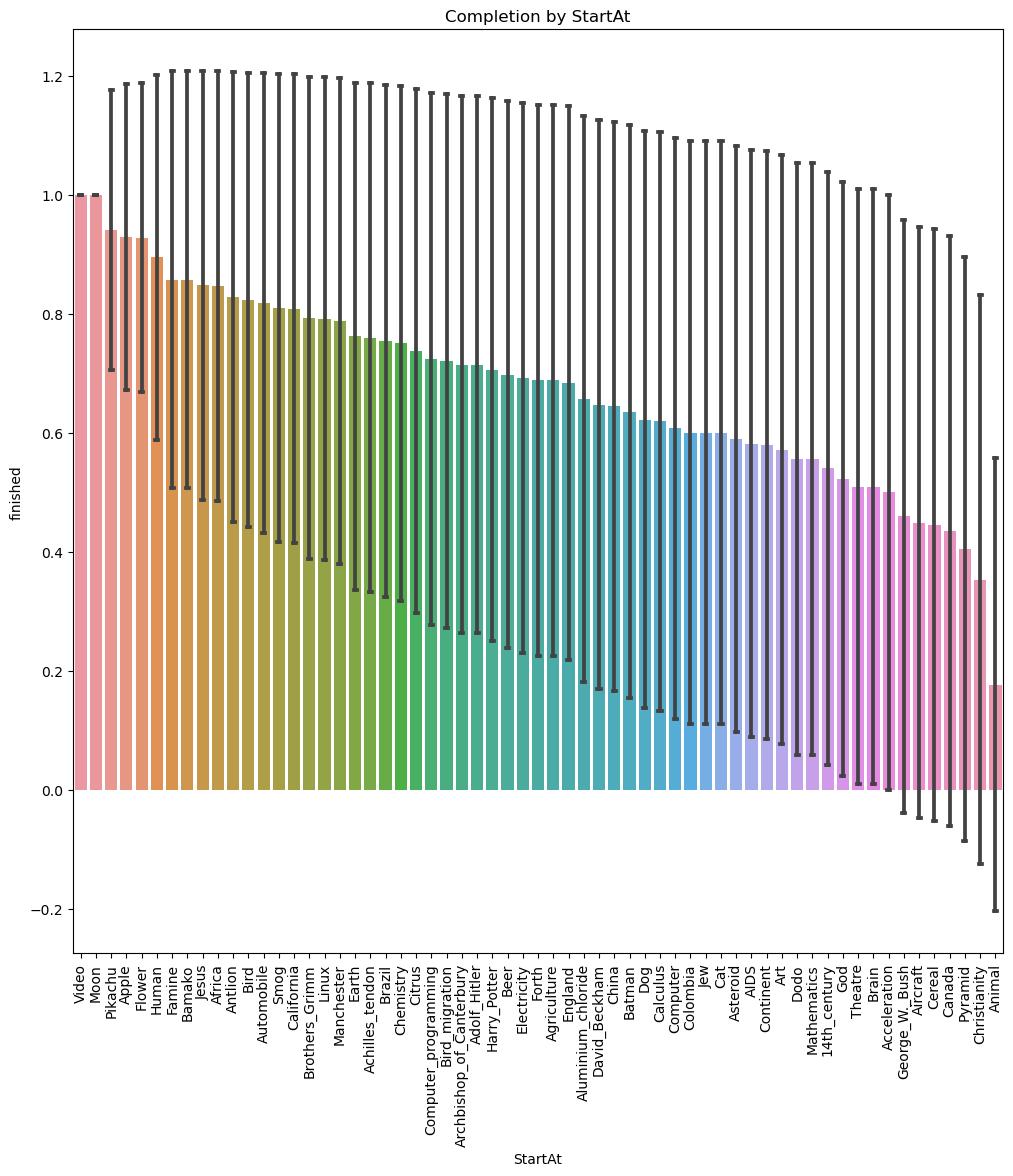

In [125]:
order = (
    reduced_trajs_df.groupby("StartAt")["finished"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 12))
sns.barplot(
    data=reduced_trajs_df,
    x="StartAt",
    y="finished",
    ci="sd",  # use standard deviation instead of CI
    order=order,
    capsize=0.2,
)
plt.xticks(rotation=90)
plt.title("Completion by StartAt")

Text(0.5, 1.0, 'Completion by EndAt')

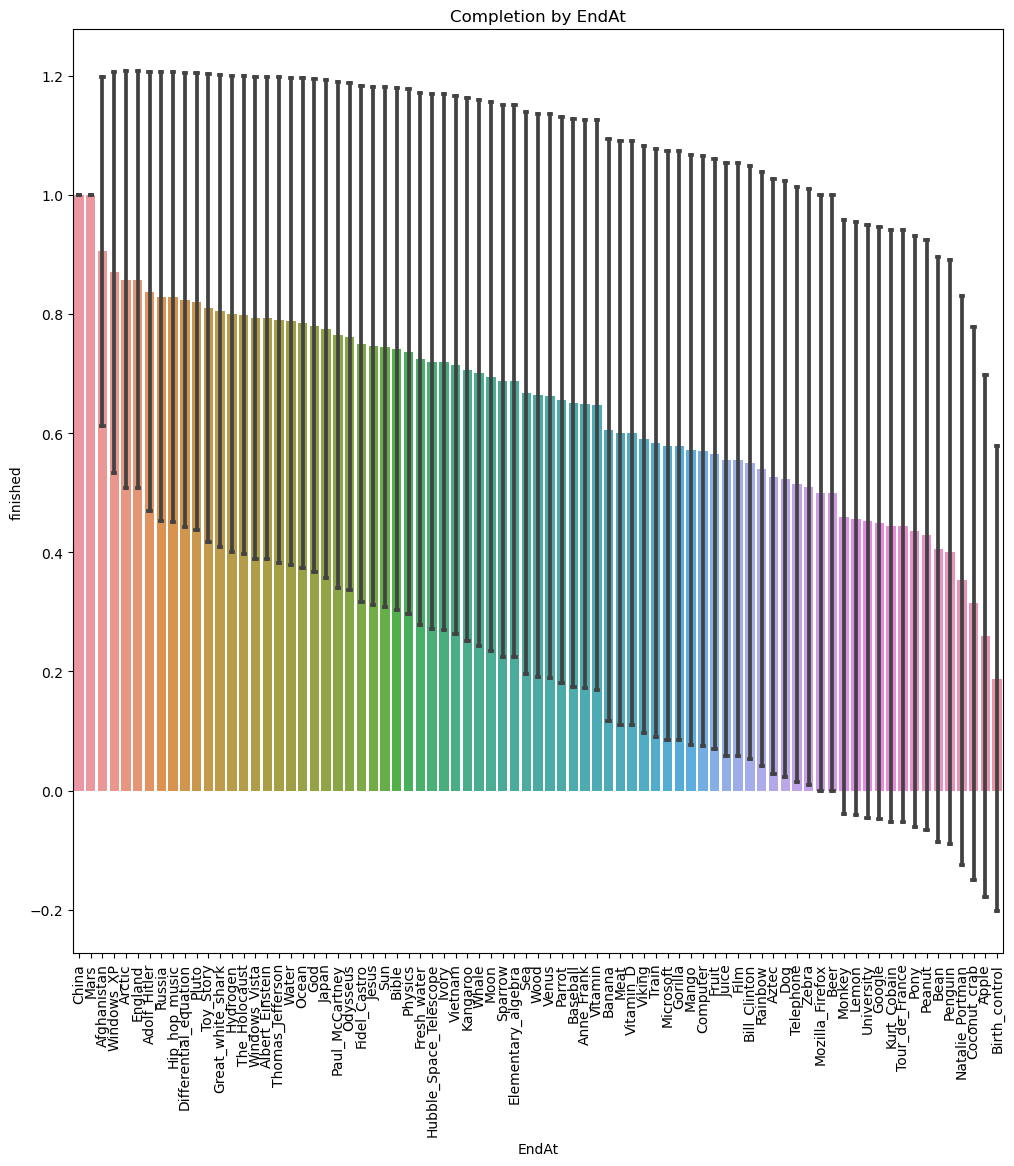

In [124]:
order = (
    reduced_trajs_df.groupby("EndAt")["finished"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(12, 12))
sns.barplot(
    data=reduced_trajs_df,
    x="EndAt",
    y="finished",
    ci="sd",  # use standard deviation instead of CI
    order=order,
    capsize=0.2,
)
plt.xticks(rotation=90)
plt.title("Completion by EndAt")

## Category Analysis

In [135]:
category_graph = nx.Graph() 
max_category_depth = categories_df["num_categories"].max()
for i in range(max_category_depth):
    category_graph.add_nodes_from(categories_df[f"category{i}"].dropna(), layer=i)

edges = []
for _, row in categories_df.iterrows():
    for i in range(max_category_depth-1):
        if pd.isna(row[f"category{i}"]) or pd.isna(row[f"category{i+1}"]):
            break
        edges.append([row[f"category{i}"], row[f"category{i+1}"]])
category_graph.add_edges_from(edges)
print(category_graph)

Graph with 142 nodes and 145 edges


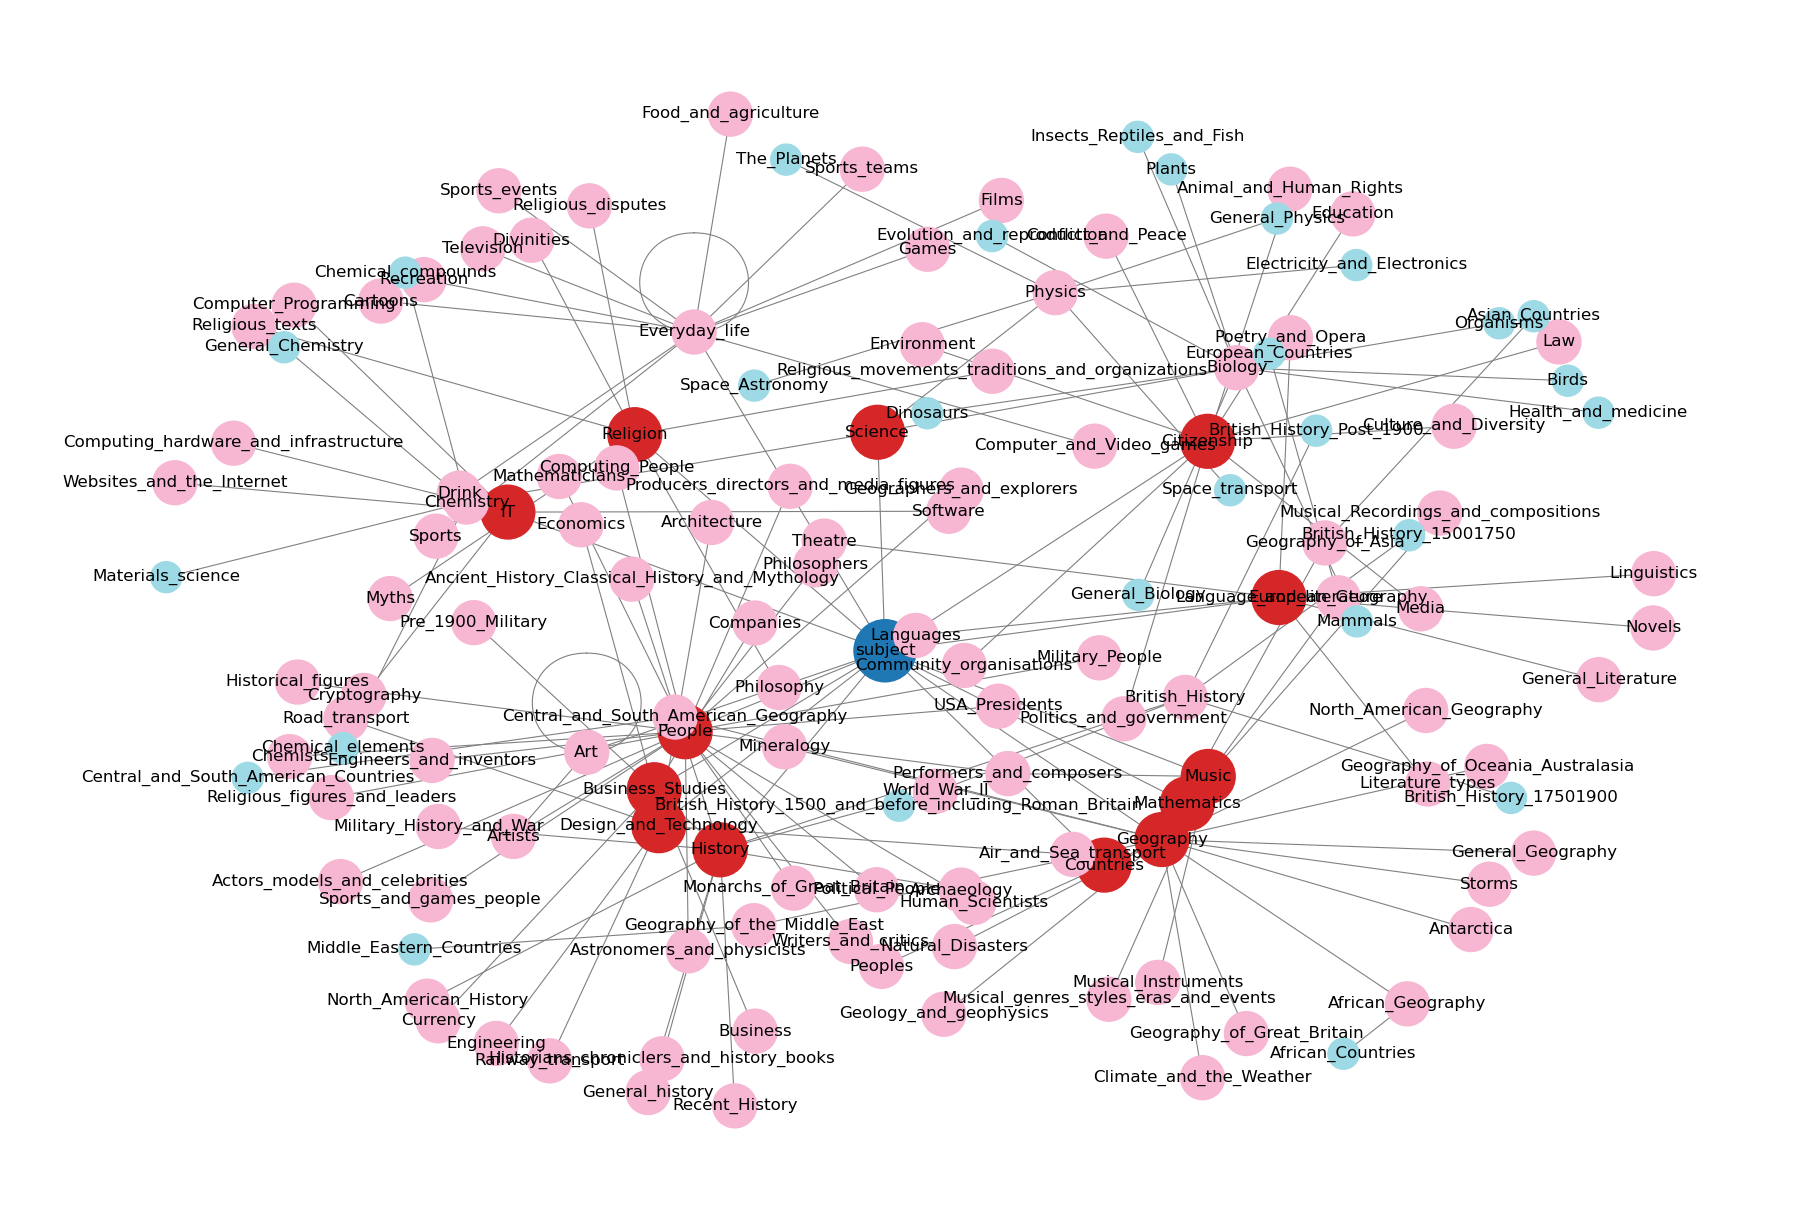

In [338]:
from networkx.drawing.nx_agraph import graphviz_layout
import matplotlib.pyplot as plt

# pos = nx.drawing.nx_agraph.graphviz_layout(category_graph, prog="dot")  # tree layout
pos = nx.spring_layout(category_graph, k=0.7, iterations=100)  # spread nodes out

layers = nx.get_node_attributes(category_graph, "layer")
node_colors = [layers[node] for node in category_graph.nodes()]
node_sizes = [2000-500*layers[node] for node in category_graph.nodes()]

plt.figure(figsize=(18, 12))  # make the figure larger
nx.draw(
    category_graph, pos,
    with_labels=True,
    node_size=node_sizes,            # bigger nodes
    node_color=node_colors,
    cmap=plt.cm.tab20,   # try 'plasma', 'tab20' for alternatives
    font_size=12,             # larger labels
    font_color='black',
    edge_color="gray",
    width=0.8,
)
plt.axis("off")
plt.show()

### Visualise graph

In [148]:
# load links
column_names = ["linkSource", "linkTarget"]
edges_df = pd.read_csv(f"{data_path}/links.tsv", names=column_names, sep='\t', skiprows=[i for i in range(13)])
edge_dict = dict(zip(edges_df.linkSource, edges_df.linkTarget))

In [149]:
category_level_dict = {}
for i in range(max_category_depth):
    for cat in categories_df[f"category{i}"].dropna():
        category_level_dict[cat] = i

for _, row in categories_df.iterrows():
    category_level_dict[row["article"]] = row["num_categories"]


print(category_level_dict)

edge_level_dict = {}
for k, v in edge_dict.items():
    if k not in category_level_dict or v not in category_level_dict:
        continue
    edge_level_dict[(k, v)] = category_level_dict[v] - category_level_dict[k]

edge_level_dict

{'subject': 0, 'History': 3, 'People': 1, 'Countries': 1, 'Geography': 3, 'Business_Studies': 1, 'Science': 3, 'Everyday_life': 2, 'Design_and_Technology': 1, 'Music': 3, 'IT': 1, 'Language_and_literature': 1, 'Mathematics': 2, 'Religion': 3, 'Art': 3, 'Citizenship': 3, 'British_History': 2, 'Historical_figures': 2, 'European_Geography': 2, 'Artists': 2, 'Currency': 3, 'General_history': 2, 'Military_History_and_War': 2, 'Physics': 4, 'Sports_events': 2, 'Storms': 2, 'Recent_History': 2, 'Geology_and_geophysics': 2, 'Natural_Disasters': 2, 'Railway_transport': 2, 'Sports_and_games_people': 2, 'Biology': 4, 'Performers_and_composers': 2, 'Computing_hardware_and_infrastructure': 2, 'Companies': 2, 'Novels': 2, 'Musical_genres_styles_eras_and_events': 2, 'Geography_of_the_Middle_East': 2, 'Ancient_History_Classical_History_and_Mythology': 2, 'Religious_movements_traditions_and_organizations': 2, 'Theatre': 3, 'Geographers_and_explorers': 2, 'Geography_of_Great_Britain': 2, 'Religious_text

{('%C3%81ed%C3%A1n_mac_Gabr%C3%A1in', 'Wales'): 0,
 ('%C3%85land', 'World_War_II'): 0,
 ('%C3%89douard_Manet', 'Washington%2C_D.C.'): 0,
 ('%C3%89ire', 'United_Kingdom'): -1,
 ('%C3%93engus_I_of_the_Picts', 'York'): 0,
 ('%E2%82%AC2_commemorative_coins', 'Zeus'): 0,
 ('10th_century', 'Viking'): 0,
 ('11th_century', 'William_I_of_England'): 0,
 ('12th_century', 'Time'): 1,
 ('13th_century', 'Time'): 1,
 ('14th_century', 'Washington%2C_D.C.'): 0,
 ('15th_Marine_Expeditionary_Unit', 'World_War_II'): 1,
 ('15th_century', 'Zheng_He'): 0,
 ('16_Cygni', 'Sun'): 0,
 ('16_Cygni_Bb', 'Water'): -1,
 ('16th_century', 'William_the_Silent'): 0,
 ('1755_Lisbon_earthquake', 'Voltaire'): 0,
 ('17th_century', 'William_Shakespeare'): 0,
 ('1896_Summer_Olympics', 'United_States'): 0,
 ('18th_century', 'Wolfgang_Amadeus_Mozart'): 0,
 ('1928_Okeechobee_Hurricane', 'United_States_Virgin_Islands'): 0,
 ('1973_oil_crisis', 'Yom_Kippur_War'): 0,
 ('1980_eruption_of_Mount_St._Helens', 'Yellowstone_National_Park'

In [161]:
G = nx.DiGraph() 

G.add_nodes_from(edges_df["linkSource"])
G.add_nodes_from(edges_df["linkTarget"])

edges = [(row["linkSource"], row["linkTarget"]) for _, row in edges_df.iterrows()]
G.add_edges_from(edges)

In [162]:
reduced_nodes = set([])
for i, x in reduced_trajs_df.iterrows():
    xx = x["path"].split(";")
    for xxx in xx:
        reduced_nodes.add(xxx)
print(reduced_nodes)

{'Galileo_Galilei', 'Coconut', 'Human_rights', 'Buffy_the_Vampire_Slayer', 'Zambia', 'Gibraltar', 'The_Holocaust', 'Slovakia', 'Black_Rhinoceros', 'Tropics', 'Taiwan', 'London_Zoo', 'Prostate_cancer', 'Republic_of_Ireland', 'Lima', 'Ottawa', 'Nickel', 'Frederick_Douglass', 'Tiger', 'India', 'Sodium', 'Battle_of_Badr', 'Gaza_Strip', 'Israel', 'Cambodia', 'Baltic_Sea', 'Pretoria', 'John_Howard', 'Age_of_Enlightenment', 'Maize', 'Mathematics', 'Pigment', 'Odyssey', 'Ice_hockey', 'Battle_of_Normandy', 'Space_Shuttle_Challenger_disaster', 'English_peasants%27_revolt_of_1381', 'Police', 'Giraffe', 'Lebanon', 'Burundi', 'Sun', 'God', 'Baboon', 'John_Locke', 'Austria', 'Radar', 'Boolean_logic', 'Pneumonia', 'Hydrochloric_acid', 'Brass_instrument', 'Coal', 'Mozambique', 'Titanium', 'Cubism', 'Space_station', 'Great_white_shark', 'Arthropod', 'Canadian_football', 'Electric_field', 'Mexico', 'Hurricane_Katrina', 'Microscope', 'Soils_retrogression_and_degradation', 'Democracy', 'Glass', 'Muhammad'

In [163]:
print(G)
G = G.subgraph(reduced_nodes).copy()
print(G)

DiGraph with 4592 nodes and 119881 edges
DiGraph with 1903 nodes and 57579 edges


In [164]:
communities = list(nx.algorithms.community.greedy_modularity_communities(G))
print(communities)
# Assign cluster IDs as node attributes
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

nx.set_node_attributes(G, community_map, "community")

[frozenset({'Dakar', 'Fine_art', 'Vanilla', 'Ho_Chi_Minh_City', 'Galileo_Galilei', 'Human_rights', 'Zambia', 'Gibraltar', 'The_Holocaust', 'Christianity', 'Nobel_Peace_Prize', 'Slovakia', 'Syria', '11th_century', 'Taiwan', 'Red_Sea', 'Iraq_War', 'History_of_science', 'Thor', 'Guadeloupe', 'Sarajevo', 'Democratic_Republic_of_the_Congo', 'Deluge_%28mythology%29', 'Cleopatra_VII', 'Art', 'African_Great_Lakes', 'Tour_de_France', 'Macedon', 'Sahara', 'India', 'Charlemagne', 'Las_Palmas_de_Gran_Canaria', 'Book', 'Gaza_Strip', 'Battle_of_Badr', 'Vincent_van_Gogh', 'Olive_oil', 'Trigonometry', 'Babur', 'Latin_alphabet', '15th_century', 'Industry', 'Lake_Tanganyika', 'Scouting', 'Cambodia', 'Israel', 'Parthenon', 'Romanticism', 'Baltic_Sea', 'Pretoria', 'C%C3%B4te_d%27Ivoire', 'Royal_Air_Force', 'Age_of_Enlightenment', 'Mathematics', 'Slovenia', 'Persian_Gulf', 'Odyssey', 'Ho_Chi_Minh', 'Battle_of_Normandy', 'World_Heritage_Site', 'Pentateuch', 'Attila_the_Hun', 'Epic_of_Gilgamesh', 'Police', '

In [165]:
print(len(communities))

6


In [168]:
from pyvis.network import Network
import random

def sample_nodes(G, fraction=0.1, seed=None):
    random.seed(seed)
    num_nodes = int(len(G) * fraction)
    sampled_nodes = random.sample(sorted(G.nodes()), num_nodes)
    return G.subgraph(sampled_nodes).copy()

G_sub = sample_nodes(G, fraction=0.3, seed=42)
print(G_sub)
net = Network(notebook=True, height="750px", width="100%", bgcolor="#222222", font_color="white")

for node, data in G_sub.nodes(data=True):
    net.add_node(node, label=str(node), group=data.get("community", 0))

for u, v in G_sub.edges():
    net.add_edge(u, v)

net.show("wikispeedia_network.html")

DiGraph with 570 nodes and 5387 edges
wikispeedia_network.html


## 2. Flow Tree analysis

In [47]:
reduced_trajs_df["path_mean_acc"] = reduced_trajs_df.groupby(["StartAt", "EndAt"])["finished"].transform("mean")

In [54]:
reduced_trajs_df.iloc[reduced_trajs_df["name_traj"].apply(len).argmax()]

hashedIpAddress                                     45e0b4ab21d0367c
timestamp                                                 1316804997
durationInSec                                                   2214
path               Pyramid;Sun;Milky_Way;Light;Eye;Organism;Life;...
rating                                                           NaN
StartAt                                                      Pyramid
EndAt                                                           Bean
finished                                                       False
target                                                          Bean
type                                                         timeout
traj_len                                                          67
levels_traj        [3, 4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 3, 4, 4, ...
level_hops         [0, 3, 2, 1, 2, 3, 3, 0, 0, 1, 0, 2, 2, 0, 2, ...
traj               [3382, 3939, 2777, 2466, 1457, 3095, 2465, 326...
StartEnd                          

In [48]:
# paths_to_plot = [path.split("_") for path in most_common_paths]

num_cols = 10
num_rows = 10

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 10, num_rows * 10))
i=0

fts = []
accs = []
rats = []
ntrajs = []
start_ends = []
thisone = reduced_trajs_df#[reduced_trajs_df["finished"]]
bb_fulls = []
bb_shortests = []
for (start_node, end_node), group in thisone.groupby(["StartAt", "EndAt"]):
    acc = group["path_mean_acc"].iloc[0]
    avg_rating = group["avg_rating"].iloc[0]

    trajs = [x for x in group["name_traj"]]#random.sample([x for x in group["name_traj"]], min(15, len(group["name_traj"]))) #random.sample(generate_trajs_from_df(this_df), min(67, len(generate_trajs_from_df(this_df))))
    G = generate_flow_tree_from_trajs(trajs)
    G.remove_edges_from(nx.selfloop_edges(G))
    backbone_path, max_weight, weights, ended_early = get_backbone_greedy(G, start_node)

    if end_node == "Fidel_Castro" and start_node == "Chemistry":
        print(backbone_path, weights)
    if not ended_early:
        shortest_path_length = int(shortest_paths[article_names.index(start_node)][article_names.index(end_node)])
        backbone_path_length = len(backbone_path[-1].split("+")) - 1 # count edges not nodes

        bb_shortests.append(shortest_path_length == backbone_path_length)
    else:
        bb_shortests.append(False)
    fts.append(G)
    accs.append(acc)
    rats.append(avg_rating)
    ntrajs.append(len(trajs))
    start_ends.append(" -> ".join([start_node, end_node]))
    bb_fulls.append(not ended_early)

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
for i, idx in enumerate(sorted_order):
    G, rat, acc, traj_len, se, bb_full, bb_sh = fts[idx], rats[idx], accs[idx], ntrajs[idx], start_ends[idx], bb_fulls[idx], bb_shortests[idx]
    
    if bb_sh:
        print("BB SHORT!", se, acc, i)
        axes[i//num_cols][i%num_cols].set_facecolor('xkcd:salmon')
        axes[i//num_cols][i%num_cols].patch.set_facecolor('xkcd:salmon')
    plot_flow_tree(G, f"{bb_full} bbshort{bb_sh} {se} ({traj_len} trajs; acc={acc:.2f}; avg rating = {rat:.2f})", axes[i//num_cols][i%num_cols], just_edges=True)
    

    


plt.savefig("figures/wikispeedia/most_common_wikispeedia-ALL22.png")
plt.show()

BB SHORT! Batman -> Penguin 0.37735849056603776 4
BB SHORT! 14th_century -> Rainbow 0.4888888888888889 14
BB SHORT! Batman -> Banana 0.5 15
BB SHORT! China -> Moon 0.6451612903225806 26
BB SHORT! AIDS -> Jesus 0.68 27
BB SHORT! Batman -> Japan 0.7307692307692307 33
BB SHORT! Achilles_tendon -> Ocean 0.7727272727272727 42
BB SHORT! Automobile -> Windows_XP 0.8695652173913043 48
BB SHORT! Flower -> Adolf_Hitler 0.9047619047619048 49


In [45]:
reduced_trajs_df["name_traj"] = reduced_trajs_df.path.apply(lambda x: x.split(";"))

In [24]:
import random

## backbone stuff??

def get_backbone_greedy(tree, root):   
    backbone_path = [root]
    backbone_weights = []

    curr_node = root
    while curr_node:
        # print("currnode", curr_node)
        best_weight = 0
        best_neighbor = None
        for neighbor in tree.neighbors(curr_node):
            # prevent go back up tree
            if neighbor in backbone_path: continue

            edge_weight = tree[curr_node][neighbor]['weight']
            # print("neigh", neighbor, "wei=", edge_weight)
            if edge_weight > best_weight: # arbitrary; pick first
                best_weight = edge_weight
                best_neighbor = neighbor

        if best_weight == 0: break

        if best_weight == 1:
            return backbone_path, backbone_weights[0], backbone_weights, True


        # can add other condition here! (backbone must be > 1/3 of mass??)

        curr_node = best_neighbor
        backbone_path.append(best_neighbor)
        backbone_weights.append(best_weight)

    return backbone_path, backbone_weights[0], backbone_weights, False

   
flow_tree_dict = {}
for (start_node, end_node), group in reduced_trajs_df.groupby(["StartAt", "EndAt"]):
    acc = group["path_mean_acc"].iloc[0]
    avg_rating = group["avg_rating"].iloc[0]

    trajs = random.sample([x for x in group["name_traj"]], min(15, len(group["name_traj"]))) #random.sample(generate_trajs_from_df(this_df), min(67, len(generate_trajs_from_df(this_df)))) 
    G = generate_flow_tree_from_trajs(trajs)
    G.remove_edges_from(nx.selfloop_edges(G))

    # print("Finding backbone for", path)
    backbone_path, max_weight, weights, ended_early = get_backbone_greedy(G, start_node)
    flow_tree_dict[(start_node, end_node)] = {
        "flow_tree": G,
        "acc": acc,
        "backbone_path": backbone_path,
        "backbone_weights": weights,
        "ended_early": ended_early
        }
    
print(flow_tree_dict)

{('14th_century', 'Rainbow'): {'flow_tree': <networkx.classes.graph.Graph object at 0x2a2461050>, 'acc': 0.4888888888888889, 'backbone_path': ['14th_century', '14th_century+Time', '14th_century+Time+Isaac_Newton'], 'backbone_weights': [3, 2], 'ended_early': True}, ('15th_century', 'Windows_Vista'): {'flow_tree': <networkx.classes.graph.Graph object at 0x2a23df510>, 'acc': 1.0, 'backbone_path': ['15th_century', '15th_century+North_America', '15th_century+North_America+United_States'], 'backbone_weights': [5, 3], 'ended_early': True}, ('AIDS', 'Jesus'): {'flow_tree': <networkx.classes.graph.Graph object at 0x2a23de9d0>, 'acc': 0.68, 'backbone_path': ['AIDS', 'AIDS+Human', 'AIDS+Human+Religion'], 'backbone_weights': [3, 2], 'ended_early': True}, ('AIDS', 'Tour_de_France'): {'flow_tree': <networkx.classes.graph.Graph object at 0x2a23dde10>, 'acc': 0.4, 'backbone_path': ['AIDS', 'AIDS+France', 'AIDS+France+Paris+Tour_de_France'], 'backbone_weights': [6, 4], 'ended_early': False}, ('Accelera

In [16]:
# ought to parse shortest paths
shortest_paths = []
with open(f"{data_path}/shortest-path-distance-matrix.txt") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#": continue

        shortest_paths.append(line)

In [27]:
back_min = 0
back_not_min = 0
ended_early = 0

for (start_node, end_node), info in flow_tree_dict.items():
    if info["ended_early"]: 
        ended_early += 1
    else:
        shortest_path_length = int(shortest_paths[article_names.index(start_node)][article_names.index(end_node)])
        backbone_path_length = len(info["backbone_path"][-1].split("+")) - 1 # count edges not nodes


        print(start_node, end_node, info)
        print(shortest_path_length, backbone_path_length)
        if shortest_path_length != backbone_path_length:
            back_not_min += 1
        else:
            back_min += 1

print(back_min, back_not_min, ended_early)

AIDS Tour_de_France {'flow_tree': <networkx.classes.graph.Graph object at 0x2a23dde10>, 'acc': 0.4, 'backbone_path': ['AIDS', 'AIDS+France', 'AIDS+France+Paris+Tour_de_France'], 'backbone_weights': [6, 4], 'ended_early': False}
2 3
Achilles_tendon Ivory {'flow_tree': <networkx.classes.graph.Graph object at 0x2a23aca90>, 'acc': 0.7, 'backbone_path': ['Achilles_tendon', 'Achilles_tendon+Achilles', 'Achilles_tendon+Achilles+Ethiopia', 'Achilles_tendon+Achilles+Ethiopia+Africa+Elephant+Ivory'], 'backbone_weights': [12, 6, 4], 'ended_early': False}
4 5
Adolf_Hitler Jesus {'flow_tree': <networkx.classes.graph.Graph object at 0x2a23ae4d0>, 'acc': 0.7, 'backbone_path': ['Adolf_Hitler', 'Adolf_Hitler+Jew', 'Adolf_Hitler+Jew+Religion+Christianity+Jesus'], 'backbone_weights': [8, 3], 'ended_early': False}
2 4
Africa England {'flow_tree': <networkx.classes.graph.Graph object at 0x2a23dd1d0>, 'acc': 0.84375, 'backbone_path': ['Africa', 'Africa+Continent', 'Africa+Continent+Europe', 'Africa+Continen